# SVM Benchmark — Holdout Evaluation

Evaluates all scikit-svm classifiers on UCI binary and multiclass datasets
using a stratified 70 % / 30 % train-test split.

**Binary datasets**: German Credit, Australian Credit, Breast Cancer
(Wisconsin Diagnostic), Ionosphere.

**Multiclass datasets**: Heart Disease (5 classes), Wine (3 classes).
Binary-only classifiers are wrapped with `OneVsRestClassifier` for
multiclass tasks.

**Metrics**: Accuracy, F1, ROC-AUC, MCC, Precision, Recall, Train time.

In [1]:
import os
import signal
import time
import warnings

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    matthews_corrcoef, precision_score, recall_score, confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC, LinearSVC
from ucimlrepo import fetch_ucirepo

import scikit_svm as sv

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.30
TIMEOUT_SECONDS = 180
RESULTS_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()

In [2]:
class Pm1Wrapper(ClassifierMixin, BaseEstimator):
    """Adapts classifiers requiring ±1 labels to arbitrary binary labels.

    Uses :class:`~sklearn.preprocessing.LabelEncoder` for encoding and
    decoding, so any two-class label type is accepted.
    """

    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, y):
        self._le = LabelEncoder()
        y_01 = self._le.fit_transform(y)               # integer 0 or 1
        self.classes_ = self._le.classes_
        y_pm1 = (2 * y_01 - 1).astype(float)           # 0 → -1,  1 → +1
        self.estimator.fit(X, y_pm1)
        return self

    def predict(self, X):
        y_pm1 = self.estimator.predict(X)
        y_01  = (y_pm1 > 0).astype(int)                # -1 → 0,  +1 → 1
        return self._le.inverse_transform(y_01)

    def decision_function(self, X):
        return self.estimator.decision_function(X)

In [3]:
class _TimeoutError(Exception):
    pass


def _timeout(seconds):
    def _handler(signum, frame):
        raise _TimeoutError(f"timed out after {seconds}s")

    def decorator(fn):
        def wrapper(*args, **kwargs):
            prev = signal.signal(signal.SIGALRM, _handler)
            signal.alarm(seconds)
            try:
                return fn(*args, **kwargs)
            finally:
                signal.alarm(0)
                signal.signal(signal.SIGALRM, prev)
        return wrapper
    return decorator

In [4]:
def _prepare_features(X_df):
    """One-hot encode categorical columns; fill missing numerics with median."""
    X_df = X_df.copy()
    cat_cols = X_df.select_dtypes(include=["object", "category"]).columns
    num_cols = X_df.select_dtypes(exclude=["object", "category"]).columns
    X_df[num_cols] = X_df[num_cols].fillna(X_df[num_cols].median())
    if len(cat_cols):
        X_df = pd.get_dummies(X_df, columns=cat_cols, drop_first=False)
    return X_df.values.astype(float)


_BINARY_SPECS = [
    (144, "German Credit",     lambda y: (y - 1).astype(int)),   # {1,2} → {0,1}
    (143, "Australian Credit", lambda y: y.astype(int)),
    ( 17, "Breast Cancer",     lambda y: LabelEncoder().fit_transform(y).astype(int)),
    ( 52, "Ionosphere",        lambda y: LabelEncoder().fit_transform(y).astype(int)),
]

_MULTICLASS_SPECS = [
    ( 45, "Heart Disease",     lambda y: y.astype(int)),          # 5 classes: 0-4
    (109, "Wine",              lambda y: LabelEncoder().fit_transform(y).astype(int)),
]


def load_datasets(specs):
    """Return {name: (X, y)} for the given spec list."""
    datasets = {}
    for ds_id, name, label_fn in specs:
        try:
            raw = fetch_ucirepo(id=ds_id)
            X = _prepare_features(raw.data.features)
            y = label_fn(raw.data.targets.values.ravel())
            n_cls = len(np.unique(y))
            print(f"  {name:<22} {X.shape[0]:>4} × {X.shape[1]:<3}  "
                  f"{n_cls} classes  {np.bincount(y).tolist()}")
            datasets[name] = (X, y)
        except Exception as exc:
            print(f"  {name:<22} FAILED — {exc}")
    return datasets

In [5]:
def get_binary_classifiers():
    """Return [(name, estimator)] accepting arbitrary binary labels."""
    clfs = []

    clfs.append(("LSVM",          Pm1Wrapper(sv.LSVM(verbose=False))))
    clfs.append(("SSVM",          Pm1Wrapper(sv.SSVM(verbose=False))))
    clfs.append(("NSSVM",         Pm1Wrapper(sv.NSSVM(verbose=False))))
    clfs.append(("PSVM",          sv.PSVMClassifier()))

    clfs.append(("LSVMK(rbf)",    Pm1Wrapper(sv.LSVMK(kernel="rbf", verbose=False))))
    clfs.append(("LSSVM(rbf)",    sv.LSSVMClassifier(kernel="rbf")))
    clfs.append(("N-PSVM",        sv.NPSVMClassifier()))
    clfs.append(("LapSVM",        sv.LapSVMClassifier()))

    if sv._HAS_LIBOCAS:
        clfs.append(("SVMOCAS",   sv.SVMOCASClassifier()))
    if sv._HAS_LIBCVM:
        clfs.append(("CVM",       Pm1Wrapper(sv.CVM())))
        clfs.append(("BVM",       Pm1Wrapper(sv.BVM())))
    if sv._HAS_LIBBSVM:
        clfs.append(("BSVM",      sv.BSVMClassifier()))
    if sv._HAS_LIBSVMLIGHT:
        clfs.append(("SVMLight",  sv.SVMLightClassifier()))
    if sv._HAS_LIBMYSVM:
        clfs.append(("MySVM",     sv.MySVMClassifier()))
    if sv._HAS_LIBLINEAR:
        clfs.append(("LibLinear", sv.LibLinearSVC()))

    clfs.append(("sklearn SVC",       SVC(kernel="rbf")))
    clfs.append(("sklearn LinearSVC", LinearSVC(max_iter=2000)))
    return clfs


def get_multiclass_classifiers():
    """Return [(name, estimator)] handling multiclass targets.

    Binary-only classifiers are wrapped with
    :class:`~sklearn.multiclass.OneVsRestClassifier`.  Classifiers that
    require ±1 labels also carry a :class:`Pm1Wrapper` inside the OvR.
    """
    OvR = OneVsRestClassifier
    clfs = []

    # ±1-only → OvR( Pm1Wrapper( base ) )
    clfs.append(("LSVM (OvR)",        OvR(Pm1Wrapper(sv.LSVM(verbose=False)))))
    clfs.append(("SSVM (OvR)",        OvR(Pm1Wrapper(sv.SSVM(verbose=False)))))
    clfs.append(("NSSVM (OvR)",       OvR(Pm1Wrapper(sv.NSSVM(verbose=False)))))
    clfs.append(("LSVMK(rbf) (OvR)",  OvR(Pm1Wrapper(sv.LSVMK(kernel="rbf", verbose=False)))))

    # Binary with internal encoding → OvR( base )
    clfs.append(("PSVM (OvR)",        OvR(sv.PSVMClassifier())))
    clfs.append(("N-PSVM (OvR)",      OvR(sv.NPSVMClassifier())))
    clfs.append(("LapSVM (OvR)",      OvR(sv.LapSVMClassifier())))

    if sv._HAS_LIBOCAS:
        clfs.append(("SVMOCAS (OvR)", OvR(sv.SVMOCASClassifier())))
    if sv._HAS_LIBCVM:
        clfs.append(("CVM (OvR)",     OvR(Pm1Wrapper(sv.CVM()))))
        clfs.append(("BVM (OvR)",     OvR(Pm1Wrapper(sv.BVM()))))
    if sv._HAS_LIBSVMLIGHT:
        clfs.append(("SVMLight (OvR)",OvR(sv.SVMLightClassifier())))
    if sv._HAS_LIBMYSVM:
        clfs.append(("MySVM (OvR)",   OvR(sv.MySVMClassifier())))

    # Native multiclass (no wrapping needed)
    clfs.append(("LSSVM(rbf)",        sv.LSSVMClassifier(kernel="rbf")))
    if sv._HAS_LIBBSVM:
        clfs.append(("BSVM",          sv.BSVMClassifier()))
    if sv._HAS_LIBLINEAR:
        clfs.append(("LibLinear",     sv.LibLinearSVC()))
    if sv._HAS_LIBOCAS:
        clfs.append(("MSVMOCAS",      sv.MSVMOCASClassifier()))

    clfs.append(("sklearn SVC",       SVC(kernel="rbf")))
    clfs.append(("sklearn LinearSVC", LinearSVC(max_iter=2000)))
    return clfs

In [6]:
def _get_scores_binary(clf, X_test):
    """1-D decision scores for binary AUC (higher → positive class)."""
    try:
        return clf.decision_function(X_test)
    except AttributeError:
        pass
    try:
        return clf.predict_proba(X_test)[:, 1]
    except AttributeError:
        return None


def _get_scores_multiclass(clf, X_test, n_classes):
    """(n, n_classes) probability matrix for multiclass AUC."""
    # 1. Try predict_proba
    try:
        proba = clf.predict_proba(X_test)
        if proba.shape[1] == n_classes:
            return proba
    except (AttributeError, NotImplementedError):
        pass
    # 2. Try decision_function — apply softmax if shape matches
    try:
        df = clf.decision_function(X_test)
        if df.ndim == 2 and df.shape[1] == n_classes:
            df = df - df.max(axis=1, keepdims=True)
            e  = np.exp(df)
            return e / e.sum(axis=1, keepdims=True)
    except (AttributeError, NotImplementedError):
        pass
    return None


@_timeout(TIMEOUT_SECONDS)
def _run_fit_predict(clf, X_train, y_train, X_test):
    t0 = time.perf_counter()
    clf.fit(X_train, y_train)
    return clf, time.perf_counter() - t0, clf.predict(X_test)


def evaluate_holdout(clf, X_train, y_train, X_test, y_test, multiclass=False):
    """Fit clf and compute test-set metrics; handles binary and multiclass."""
    try:
        clf, train_time, y_pred = _run_fit_predict(clf, X_train, y_train, X_test)
    except _TimeoutError as exc:
        return {"Status": f"TIMEOUT ({exc})"}
    except Exception as exc:
        return {"Status": f"ERROR: {exc}"}

    avg = "weighted" if multiclass else "binary"
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average=avg, zero_division=0)
    mcc  = matthews_corrcoef(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average=avg, zero_division=0)
    rec  = recall_score(y_test, y_pred, average=avg, zero_division=0)

    n_classes = len(np.unique(y_test))
    auc = float("nan")
    if multiclass:
        scores = _get_scores_multiclass(clf, X_test, n_classes)
        if scores is not None:
            try:
                auc = roc_auc_score(y_test, scores, multi_class="ovr", average="weighted")
            except Exception:
                pass
    else:
        scores = _get_scores_binary(clf, X_test)
        if scores is not None:
            try:
                auc = roc_auc_score(y_test, scores)
                if auc < 0.5:
                    auc = 1.0 - auc
            except Exception:
                pass

    row = {
        "Accuracy":      round(acc,  4),
        "F1":            round(f1,   4),
        "AUC":           round(auc,  4) if not np.isnan(auc) else float("nan"),
        "MCC":           round(mcc,  4),
        "Precision":     round(prec, 4),
        "Recall":        round(rec,  4),
        "Train time (s)":round(train_time, 3),
        "Status":        "OK",
    }
    if not multiclass:
        cm = confusion_matrix(y_test, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            row.update({"TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn)})
    return row

In [7]:
def run_benchmark(datasets, classifiers, multiclass=False):
    records = []
    tag = "multiclass" if multiclass else "binary"

    for ds_name, (X, y) in datasets.items():
        n_cls = len(np.unique(y))
        sep   = "─" * 64
        print(sep)
        print(f"  [{tag}] {ds_name}  ({X.shape[0]} × {X.shape[1]}, "
              f"{n_cls} classes: {np.bincount(y).tolist()})")
        print(sep)

        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
        )
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        for clf_name, clf_proto in classifiers:
            clf = clone(clf_proto)
            print(f"  {clf_name:<28}", end="", flush=True)
            m = evaluate_holdout(clf, X_tr, y_tr, X_te, y_te, multiclass=multiclass)
            status = m.get("Status", "OK")
            if status == "OK":
                auc_s = f"{m['AUC']:.4f}" if not np.isnan(m["AUC"]) else "N/A "
                print(f"  Acc={m['Accuracy']:.4f}  AUC={auc_s:>6}  "
                      f"F1={m['F1']:.4f}  time={m['Train time (s)']:.3f}s")
            else:
                print(f"  {status}")
            records.append({
                "Dataset":    ds_name,
                "Classifier": clf_name,
                "Task":       tag,
                "n_train":    len(y_tr),
                "n_test":     len(y_te),
                "n_features": X.shape[1],
                "n_classes":  n_cls,
                **m,
            })

        print()

    return pd.DataFrame(records)

In [8]:
_METRIC_COLS = ["Accuracy", "F1", "AUC", "MCC", "Precision", "Recall", "Train time (s)"]


def display_summary(df, task_label):
    ok = df[df["Status"] == "OK"]

    print(f"\n{'='*80}")
    print(f"  {task_label.upper()} — FULL RESULTS PER DATASET")
    print(f"{'='*80}")
    for ds_name, grp in df.groupby("Dataset"):
        print(f"\n── {ds_name} ──")
        sub = grp[["Classifier"] + _METRIC_COLS + ["Status"]].set_index("Classifier")
        print(sub.to_string())

    if ok.empty:
        return

    print(f"\n{'='*80}")
    print(f"  {task_label.upper()} — BEST ACCURACY PER DATASET")
    print(f"{'='*80}")
    best_rows = []
    for _, grp in ok.groupby("Dataset"):
        best_rows.append(grp.loc[grp["Accuracy"].idxmax()])
    best = pd.DataFrame(best_rows)[["Dataset", "Classifier", "Accuracy", "F1", "AUC",
                                     "MCC", "Train time (s)"]]
    print(best.to_string(index=False))

    print(f"\n{'='*80}")
    print(f"  {task_label.upper()} — AVERAGE ACCURACY PER CLASSIFIER")
    print(f"{'='*80}")
    avg = (
        ok.groupby("Classifier")["Accuracy"]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "Avg Acc", "std": "Std", "count": "Datasets"})
        .sort_values("Avg Acc", ascending=False)
    )
    print(avg.to_string())

In [9]:
def plot_results(df, title, save_path=None):
    ok = df[df["Status"] == "OK"].copy()
    if ok.empty:
        print("No successful results to plot.")
        return

    n_clf = len(ok["Classifier"].unique())
    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, n_clf * 0.4 + 2)))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    acc_pivot = ok.pivot_table(index="Classifier", columns="Dataset", values="Accuracy")
    sns.heatmap(acc_pivot, ax=axes[0], annot=True, fmt=".3f",
                cmap="RdYlGn", vmin=0.5, vmax=1.0, linewidths=0.5,
                cbar_kws={"label": "Accuracy"})
    axes[0].set_title("Accuracy")
    axes[0].tick_params(axis="x", rotation=35)
    axes[0].tick_params(axis="y", rotation=0)

    time_pivot = ok.pivot_table(index="Classifier", columns="Dataset",
                                values="Train time (s)")
    log_time = np.log1p(time_pivot)
    sns.heatmap(log_time, ax=axes[1],
                annot=time_pivot.map(lambda v: f"{v:.2f}" if not np.isnan(v) else ""),
                fmt="", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={"label": "log(1 + seconds)"})
    axes[1].set_title("Train time (s)  [log colour scale]")
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].tick_params(axis="y", rotation=0)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Figure saved → {save_path}")
    plt.show()

  LOADING BINARY DATASETS


  German Credit          1000 × 61   2 classes  [700, 300]


  Australian Credit       690 × 14   2 classes  [383, 307]


  Breast Cancer           569 × 30   2 classes  [357, 212]


  Ionosphere              351 × 34   2 classes  [126, 225]

  LOADING MULTICLASS DATASETS


...

  Acc=0.9815  AUC=1.0000  F1=0.9814  time=0.003s
  sklearn LinearSVC           

  Acc=0.9815  AUC=0.9983  F1=0.9815  time=0.001s


  BINARY BENCHMARK — FULL RESULTS PER DATASET

── Australian Credit ──
                   Accuracy      F1     AUC     MCC  Precision  Recall  Train time (s) Status
Classifier                                                                                   
LSVM                 0.8502  0.8410  0.9336  0.7043     0.7961  0.8913           0.002     OK
SSVM                 0.8406  0.8406  0.9294  0.7022     0.7565  0.9457           0.196     OK
NSSVM                0.5604  0.0619  0.8685  0.0493     0.6000  0.0326           0.549     OK
PSVM                 0.8406  0.8406  0.9257  0.7022     0.7565  0.9457           0.019     OK
LSVMK(rbf)           0.8406  0.7925  0.9255  0.6903     0.9403  0.6848           0.041     OK
LSSVM(rbf)           0.8261  0.8022  0.8773  0.6472     0.8111  0.7935           0.071     OK
N-PSVM               0.6039  0.2264  0.8677  0.2237     0.8571  0.1304           0.330     OK
LapSVM               0.8406  0.8

                   Accuracy      F1     AUC     MCC  Precision  Recall  Train time (s) Status
Classifier                                                                                   
LSVM                 0.7467  0.5824  0.8017  0.4007     0.5761  0.5889           0.016     OK
SSVM                 0.7633  0.5644  0.7989  0.4085     0.6301  0.5111           0.957     OK
NSSVM                0.7000  0.0000  0.6785  0.0000     0.0000  0.0000           0.934     OK
PSVM                 0.7733  0.5584  0.8010  0.4226     0.6719  0.4778           0.025     OK
LSVMK(rbf)           0.7000  0.0000  0.6059  0.0000     0.0000  0.0000           0.178     OK
LSSVM(rbf)           0.7000  0.0000  0.6853  0.0000     0.0000  0.0000           0.206     OK
N-PSVM               0.7000  0.0000  0.6790  0.0000     0.0000  0.0000           0.356     OK
LapSVM               0.6933  0.4588  0.6763  0.2467     0.4875  0.4333           3.720     OK
SVMOCAS              0.7733  0.5641  0.7832  0.4249     0.66


Results saved → /mnt/DATA/Darbas/projects/scikit-svm/benchmarks/results_holdout.csv


  Figure saved → /mnt/DATA/Darbas/projects/scikit-svm/benchmarks/results_holdout_binary.png


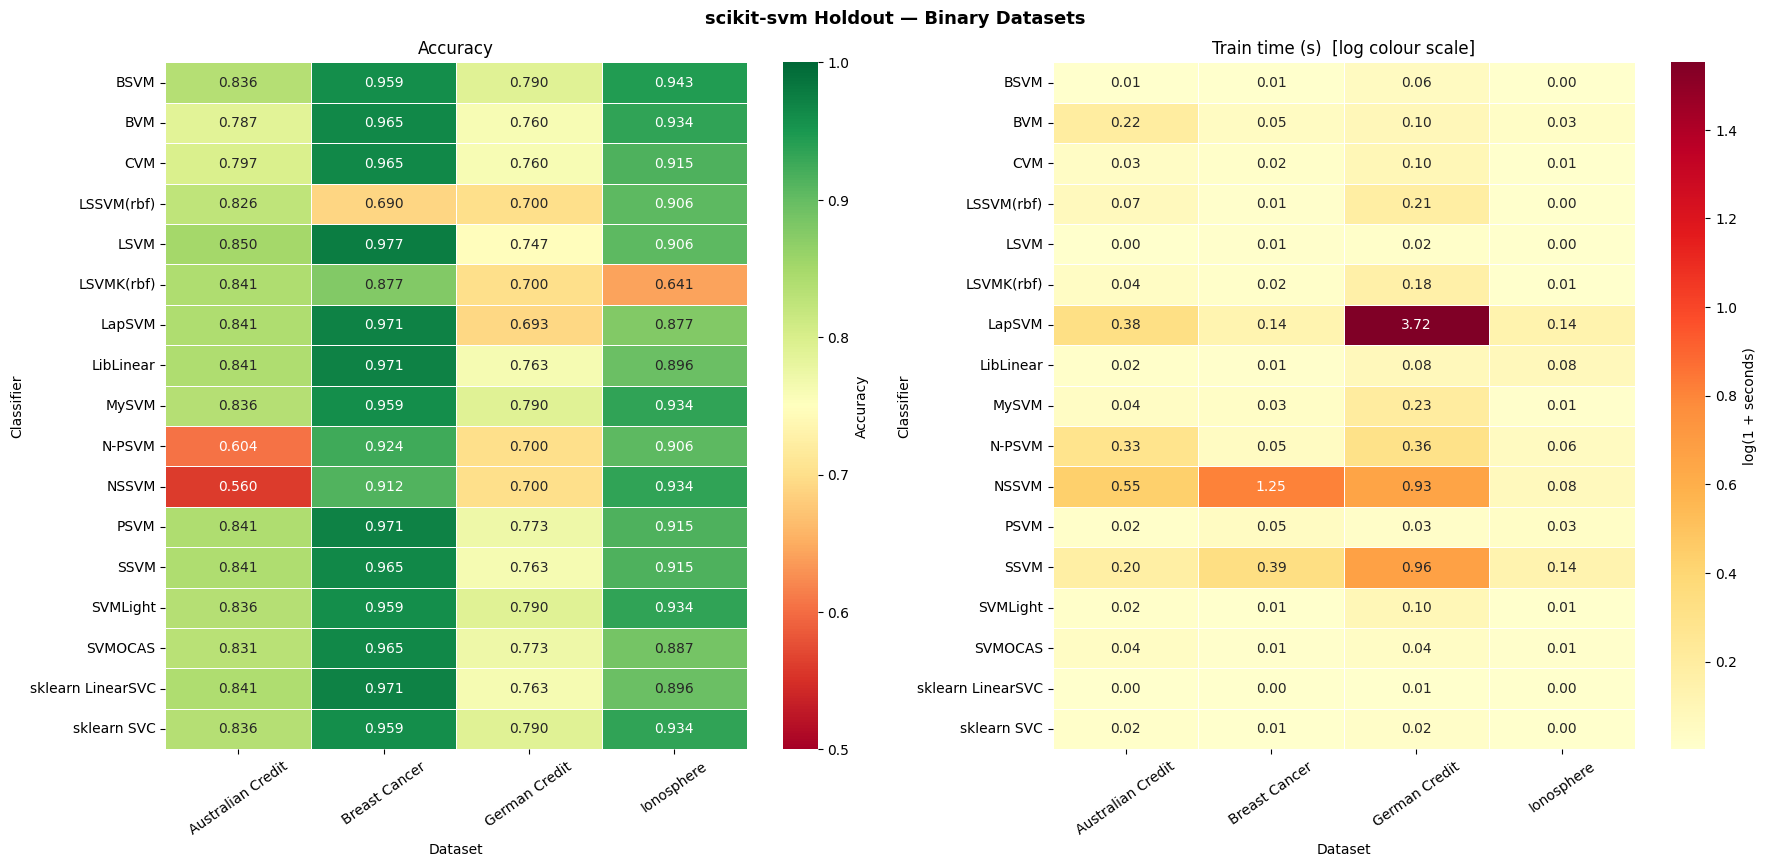

  Figure saved → /mnt/DATA/Darbas/projects/scikit-svm/benchmarks/results_holdout_multiclass.png


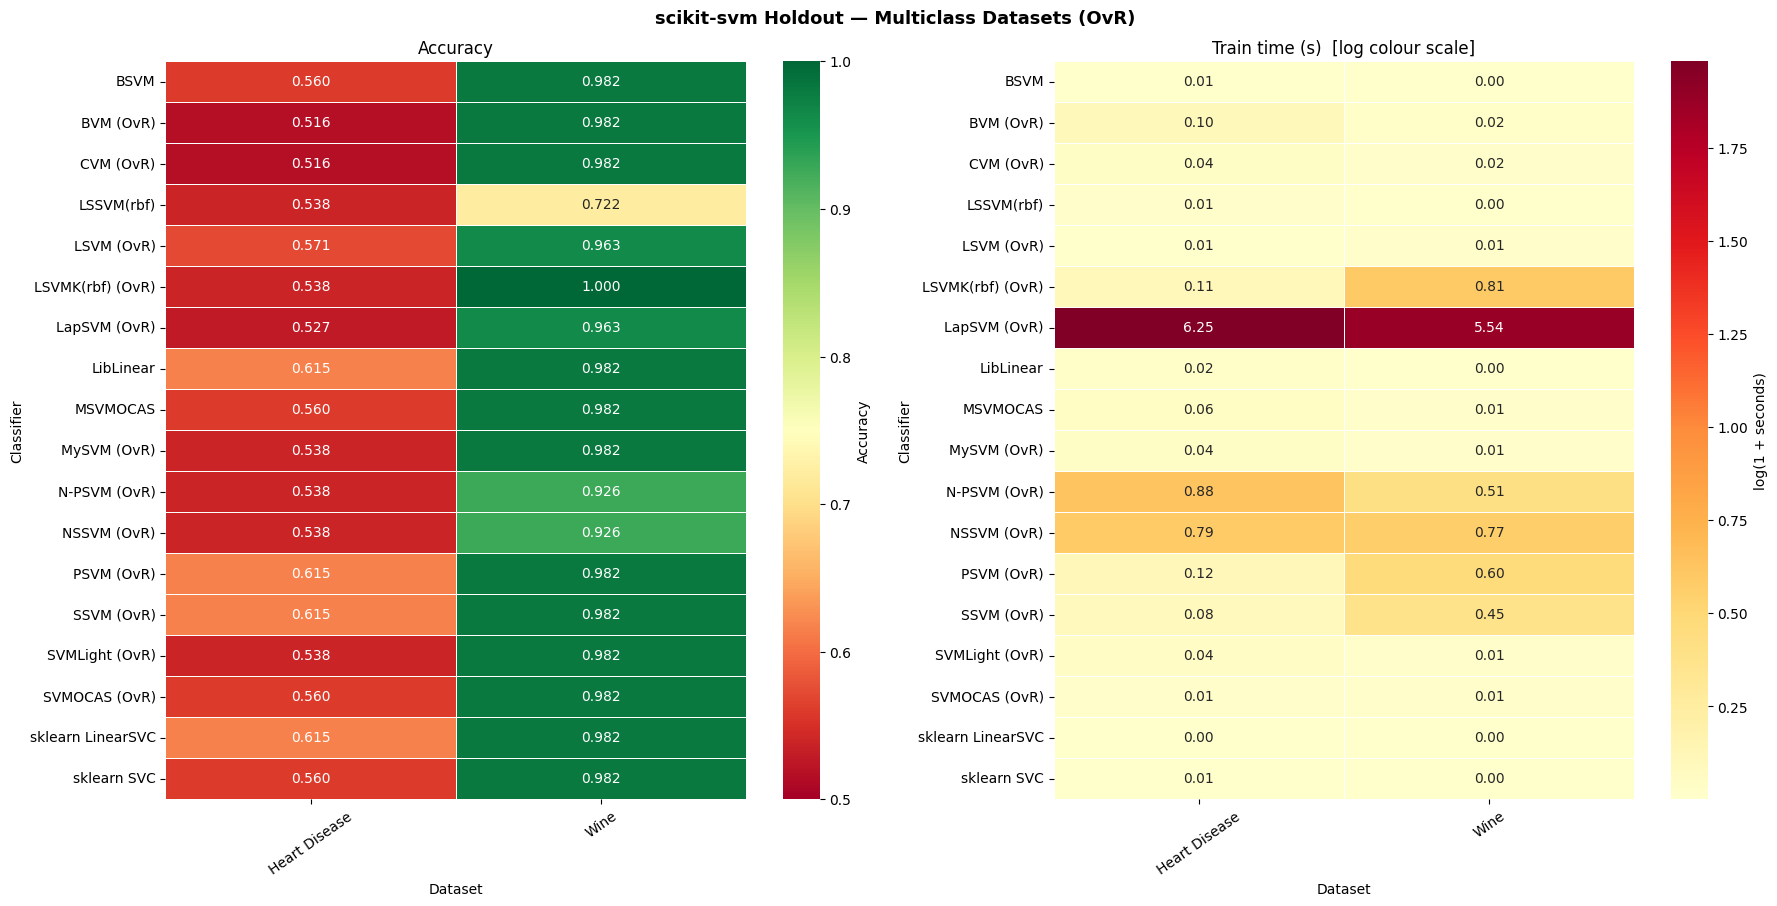

In [10]:
if __name__ == "__main__":
    print("=" * 64)
    print("  LOADING BINARY DATASETS")
    print("=" * 64)
    binary_datasets = load_datasets(_BINARY_SPECS)
    print()

    print("=" * 64)
    print("  LOADING MULTICLASS DATASETS")
    print("=" * 64)
    multi_datasets = load_datasets(_MULTICLASS_SPECS)
    print()

    binary_clfs = get_binary_classifiers()
    multi_clfs  = get_multiclass_classifiers()

    df_binary = run_benchmark(binary_datasets, binary_clfs, multiclass=False)
    df_multi  = run_benchmark(multi_datasets,  multi_clfs,  multiclass=True)

    display_summary(df_binary, "binary benchmark")
    display_summary(df_multi,  "multiclass benchmark")

    df_all = pd.concat([df_binary, df_multi], ignore_index=True)
    csv_path = os.path.join(RESULTS_DIR, "results_holdout.csv")
    df_all.to_csv(csv_path, index=False)
    print(f"\nResults saved → {csv_path}")

    plot_results(df_binary, "scikit-svm Holdout — Binary Datasets",
                 save_path=os.path.join(RESULTS_DIR, "results_holdout_binary.png"))
    plot_results(df_multi,  "scikit-svm Holdout — Multiclass Datasets (OvR)",
                 save_path=os.path.join(RESULTS_DIR, "results_holdout_multiclass.png"))